<a href="https://colab.research.google.com/github/AchyuthaAshish/AI-ML-Projects/blob/main/01_Email_Spam_Detection/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import os
import tarfile
import urllib.request
import pandas as pd

# SpamAssassin public email corpus
urls = {
    "easy_ham": "https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2",
    "easy_ham_2": "https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham_2.tar.bz2",
    "hard_ham": "https://spamassassin.apache.org/old/publiccorpus/20030228_hard_ham.tar.bz2",
    "spam": "https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2",
    "spam_2": "https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2"
}

os.makedirs("spam_dataset", exist_ok=True)

for name, url in urls.items():

    file_path = f"spam_dataset/{name}.tar.bz2"

    print(f"Downloading {name}...")

    urllib.request.urlretrieve(url, file_path)

    print(f"Extracting {name}...")

    with tarfile.open(file_path, "r:bz2") as tar:
        tar.extractall("spam_dataset")

print("\n✅ Dataset downloaded and extracted successfully!")

Extracting easy_ham...


/tmp/ipykernel_5057/2823903557.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("spam_dataset")


Extracting easy_ham_2...
Extracting hard_ham...
Extracting spam...
Extracting spam_2...

✅ Dataset downloaded and extracted successfully!


In [3]:
import os
import pandas as pd

emails = []
labels = []

dataset_path = "spam_dataset"

for root, dirs, files in os.walk(dataset_path):

    # Get the actual dataset folder name
    folder_name = os.path.basename(root).lower()

    # Determine label from the immediate folder
    if "ham" in folder_name:
        label = "ham"

    elif "spam" in folder_name:
        label = "spam"

    else:
        continue

    for filename in files:

        file_path = os.path.join(root, filename)

        # Skip archive files
        if filename.endswith(".tar.bz2"):
            continue

        try:
            with open(file_path, "r", encoding="latin-1") as f:
                text = f.read()

            if text.strip():
                emails.append(text)
                labels.append(label)

        except Exception:
            continue


df = pd.DataFrame({
    "email": emails,
    "label": labels
})

print("✅ Emails loaded successfully!")
print("Total emails:", len(df))

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nDataset shape:", df.shape)

✅ Emails loaded successfully!
Total emails: 6051

Class distribution:
label
ham     4153
spam    1898
Name: count, dtype: int64

Dataset shape: (6051, 2)


In [4]:
df.dropna(inplace=True)
df.drop_duplicates(subset="email", inplace=True)
df.reset_index(drop=True, inplace=True)

print("Dataset after cleaning:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())

Dataset after cleaning: (6051, 2)

Class distribution:
label
ham     4153
spam    1898
Name: count, dtype: int64


In [5]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nTarget distribution:")
print(df["target"].value_counts())


Target distribution:
target
0    4153
1    1898
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split

X = df["email"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training emails:", len(X_train))
print("Testing emails :", len(X_test))

Training emails: 4840
Testing emails : 1211


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape :", X_test_tfidf.shape)

TF-IDF training shape: (4840, 50000)
TF-IDF testing shape : (1211, 50000)


In [8]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("          EMAIL SPAM DETECTION RESULTS")
print("=" * 60)

print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["HAM", "SPAM"]
))

          EMAIL SPAM DETECTION RESULTS
Accuracy  : 97.69%
Precision : 95.60%
Recall    : 97.11%
F1 Score  : 96.34%

Classification Report:
              precision    recall  f1-score   support

         HAM       0.99      0.98      0.98       831
        SPAM       0.96      0.97      0.96       380

    accuracy                           0.98      1211
   macro avg       0.97      0.98      0.97      1211
weighted avg       0.98      0.98      0.98      1211



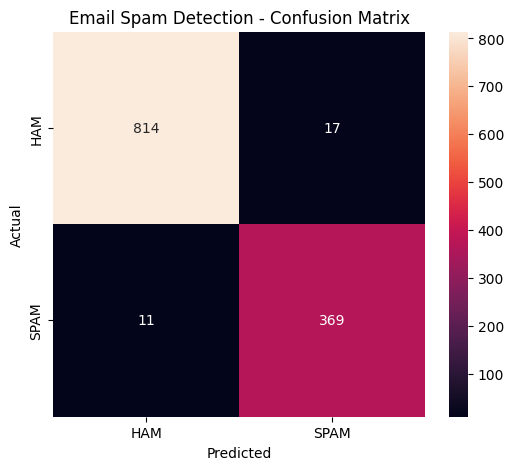

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["HAM", "SPAM"],
    yticklabels=["HAM", "SPAM"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Email Spam Detection - Confusion Matrix")

plt.show()

In [11]:
def detect_spam(email_text):

    # Convert email to TF-IDF
    email_tfidf = tfidf.transform([email_text])

    # Prediction
    prediction = model.predict(email_tfidf)[0]

    # Probability
    probabilities = model.predict_proba(email_tfidf)[0]

    ham_probability = probabilities[0]
    spam_probability = probabilities[1]

    if prediction == 1:
        result = "SPAM"
    else:
        result = "HAM"

    return result, ham_probability, spam_probability

In [12]:
print("=" * 70)
print("                  EMAIL SPAM DETECTOR")
print("=" * 70)

email = input("\nEnter your email text: ")

result, ham_probability, spam_probability = detect_spam(email)

print("\n" + "=" * 70)
print("                         RESULT")
print("=" * 70)

print("Email Text       :", email)
print("Classification   :", result)
print("HAM Probability  :", f"{ham_probability * 100:.2f}%")
print("SPAM Probability :", f"{spam_probability * 100:.2f}%")

if result == "SPAM":

    print("\n⚠️ WARNING: This email is likely SPAM.")

else:

    print("\n✅ This email appears to be HAM (Legitimate).")

                  EMAIL SPAM DETECTOR

Enter your email text: Congratulations! You have won $1,000,000 in our lottery. Click here immediately to claim your prize!

                         RESULT
Email Text       : Congratulations! You have won $1,000,000 in our lottery. Click here immediately to claim your prize!
Classification   : SPAM
HAM Probability  : 26.39%
SPAM Probability : 73.61%

⚠️ WARNING: This email is likely SPAM.


In [13]:
import joblib

joblib.dump(model, "spam_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("✅ Model and TF-IDF vectorizer saved successfully!")

✅ Model and TF-IDF vectorizer saved successfully!
